# Hands-on Sesi 4

Nama Lengkap : Rexxy Andrew Gunawan

NIM          : 240401010223

Kelas        : IF403

Program Studi: S1 PJJ Informatika UNSIA

Mata Kuliah  : Data Science

Disusun oleh : Rexxy Andrew Gunawan

Link Google Colab: https://colab.research.google.com/drive/1DQ2Ab2_wuTw1lval5dEl51KTYS2rd5Q4?authuser=3#scrollTo=pXMOdO1Ing1d

# 1. Load & Inspect Dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


### Membuat Dataset Sintetik Baru

In [9]:
np.random.seed(42) # for reproducibility

n_samples = 150
# Define parameters for 3 synthetic species
species_names = ['FlowerA', 'FlowerB', 'FlowerC']
n_species = len(species_names)
samples_per_species = n_samples // n_species

# Generate data for each species
sepal_length = []
sepal_width = []
petal_length = []
petal_width = []
species = []

for i, name in enumerate(species_names):
    # Adjust means slightly for each "species" to create separation
    # These values are just examples to create distinct clusters
    sepal_length.extend(np.random.normal(loc=5.5 + i*0.5, scale=0.5, size=samples_per_species))
    sepal_width.extend(np.random.normal(loc=3.0 + i*0.2, scale=0.3, size=samples_per_species))
    petal_length.extend(np.random.normal(loc=1.5 + i*1.5, scale=0.7, size=samples_per_species))
    petal_width.extend(np.random.normal(loc=0.3 + i*0.8, scale=0.2, size=samples_per_species))
    species.extend([name] * samples_per_species)

# Ensure total samples match n_samples in case of division remainder
remaining_samples = n_samples - len(sepal_length)
if remaining_samples > 0:
    # Add remaining samples to the last species
    sepal_length.extend(np.random.normal(loc=5.5 + (n_species-1)*0.5, scale=0.5, size=remaining_samples))
    sepal_width.extend(np.random.normal(loc=3.0 + (n_species-1)*0.2, scale=0.3, size=remaining_samples))
    petal_length.extend(np.random.normal(loc=1.5 + (n_species-1)*1.5, scale=0.7, size=remaining_samples))
    petal_width.extend(np.random.normal(loc=0.3 + (n_species-1)*0.8, scale=0.2, size=remaining_samples))
    species.extend([species_names[n_species-1]] * remaining_samples)

# Create DataFrame
new_df = pd.DataFrame({
    'sepal_length': sepal_length,
    'sepal_width': sepal_width,
    'petal_length': petal_length,
    'petal_width': petal_width,
    'species': species
})

# Ensure positive values (measurements cannot be negative)
new_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']] = new_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].apply(lambda x: x.clip(lower=0.1))

# Display the head of the new dataframe
print("Synthetic Dataset Head:")
display(new_df.head())

Synthetic Dataset Head:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.748357,3.097225,0.509240,0.350099,FlowerA
1,5.430868,2.884475,1.205548,0.369290,FlowerA
2,5.823844,2.796923,1.260100,0.163995,FlowerA
3,6.261515,3.183503,0.938406,0.346451,FlowerA
4,5.382923,3.309300,1.387100,0.358614,FlowerA


In [10]:
df = sns.load_dataset('iris')

print('Shape:', '\n',
      df.shape, 2*'\n',
      df.dtypes, 2*'\n',
      df.head(), 2*'\n',
      df.describe().round(3))


Shape: 
 (150, 5) 

 sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object 

    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa 

        sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300   

# 2. Statistik Deskriptif Lengkap

In [11]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n==={col_name}===')
    print(f'Mean    : {col.mean():.3f}')
    print(f'Median  : {col.median():.3f}')
    print(f'Std Dev : {col.std():.3f}')
    print(f'Skewness: {col.skew():.3f}')
    print(f'Kurtosis: {col.kurt():.3f}')


===sepal_length===
Mean    : 5.843
Median  : 5.800
Std Dev : 0.828
Skewness: 0.315
Kurtosis: -0.552

===sepal_width===
Mean    : 3.057
Median  : 3.000
Std Dev : 0.436
Skewness: 0.319
Kurtosis: 0.228

===petal_length===
Mean    : 3.758
Median  : 4.350
Std Dev : 1.765
Skewness: -0.275
Kurtosis: -1.402

===petal_width===
Mean    : 1.199
Median  : 1.300
Std Dev : 0.762
Skewness: -0.103
Kurtosis: -1.341


# 3. Analisis Distribusi (Histogram + KDE)

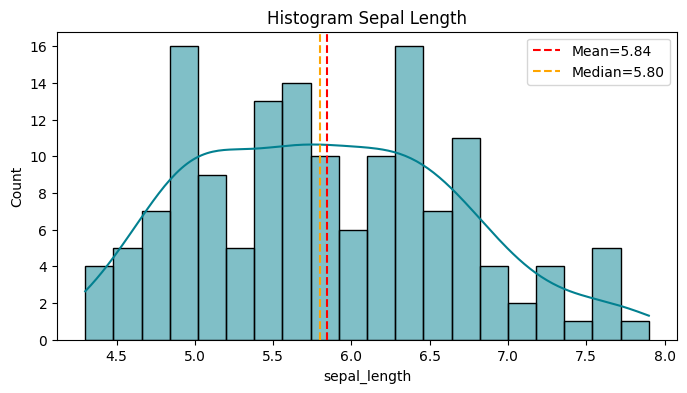

In [12]:
fig, ax=plt.subplots(figsize=(8,4))
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red', linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange', linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Histogram Sepal Length')
ax.legend()
plt.show()

# 4. Boxplot per Spesies

/tmp/ipykernel_1984/2187850409.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=ax[0])
/tmp/ipykernel_1984/2187850409.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=ax[1])


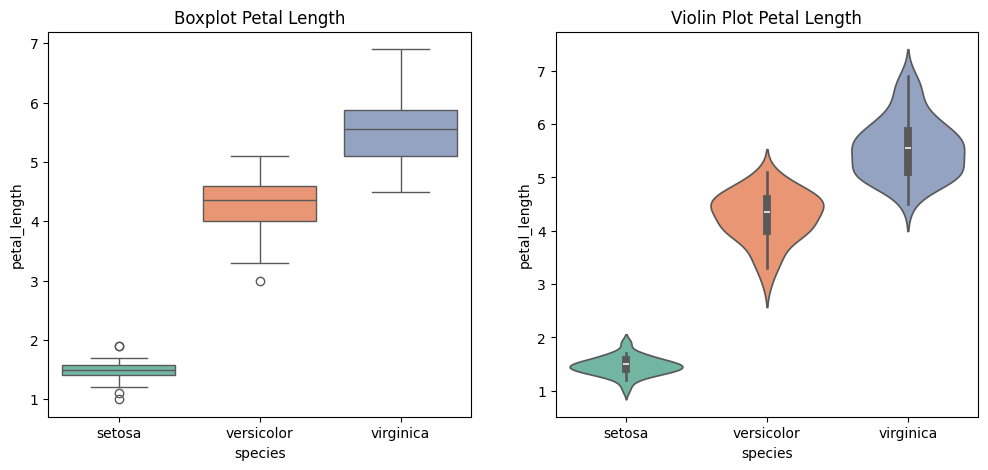

In [13]:
fig, ax=plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=ax[0])
ax[0].set_title('Boxplot Petal Length')
sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=ax[1])
ax[1].set_title('Violin Plot Petal Length')
plt.show()

# 5. Matriks Korelasi Pearson

In [14]:
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3), '\n')

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000 

Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


# 6. Scatter Plot & Heatmap

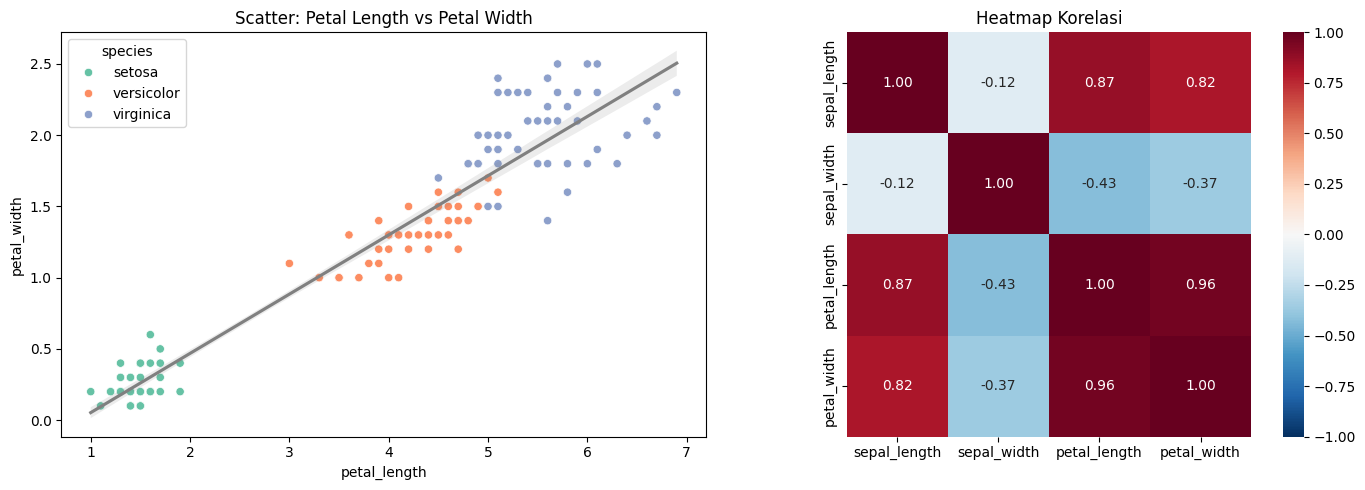

In [15]:
fig, axes=plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout()
plt.show()

## Interpretasi

Scatter plot menunjukkan hubungan linear positif yang sangat kuat
antara petal_length dan petal_width. Semakin panjang petal bunga,
maka lebar petalnya juga cenderung meningkat.

Berdasarkan warna spesies, terlihat bahwa:
- setosa memiliki panjang petal paling kecil,
- versicolor berada di tengah,
- virginica memiliki panjang petal tertinggi.

Heatmap korelasi menunjukkan bahwa petal_length dan petal_width memiliki korelasi tertinggi sebesar 0.96, yang termasuk kategori korelasi sangat kuat dan positif.

Sebaliknya, sepal_width memiliki korelasi negatif lemah hingga sedang
terhadap variabel lainnya.

# Kesimpulan Sesi Pembelajaran Sesi 4

*   Apa yang telah dipelajari: Saya telah mempraktikkan penggunaan statistika deskriptif (ukuran pemusatan dan penyebaran) serta teknik visualisasi data untuk analisis univariat dan bivariat menggunakan library Matplotlib dan Seaborn.

*   Temuan utama: Berdasarkan analisis pada dataset Iris, ditemukan hubungan linear positif yang sangat kuat antara petal_length dan petal_width dengan koefisien korelasi sebesar 0.963. Selain itu, visualisasi menunjukkan pemisahan yang jelas antar spesies, di mana Iris Setosa memiliki ukuran petal terkecil dibandingkan spesies lainnya.

*   Keterbatasan atau pertanyaan: Saya sangat tertarik untuk mengeksplorasi lebih lanjut mengenai penggunaan Violin Plot karena ini adalah pertama kalinya saya menggunakannya.